# Masking Data BRAINSTORMING

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
img = cv2.imread(r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Dataset Eyedefy\India\1\20200118_164733_forniceal_palpebral.png')
cv2.imshow('Visualisasi CV2', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

Membaca gambar dari: C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Dataset Eyedefy\India\4\20200124_160522_forniceal_palpebral.png
(1067, 800, 4)
Format terdeteksi: BGRA (4 Channel). Mengonversi ke RGBA...


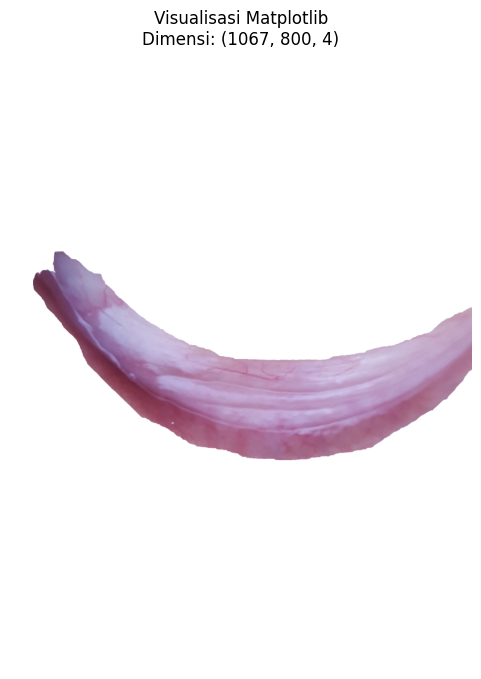

Membaca gambar dari: C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Dataset Eyedefy\Italy\6\006_forniceal_palpebral.png
(1067, 800, 4)
Format terdeteksi: BGRA (4 Channel). Mengonversi ke RGBA...


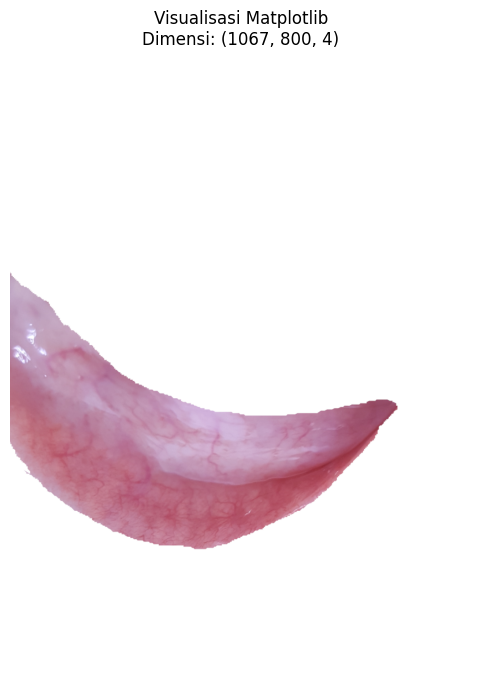

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(img_path):
    print(f"Membaca gambar dari: {img_path}")
    
    # 1. Baca gambar dengan UNCHANGED agar Alpha Channel (transparansi) tidak dibuang
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    
    if img is None:
        print("ERROR: Gambar gagal dibaca. Pastikan path benar!")
        return

    if img.dtype == np.uint16:
        print("Peringatan: Gambar 16-bit terdeteksi! Mengonversi ke 8-bit...")
        # Ubah skala 0-65535 menjadi 0-255
        img = (img / 256).astype(np.uint8)

    # Siapkan figure Matplotlib
    plt.figure(figsize=(8, 8))
    
    # 2. Cek dimensi dan lakukan konversi yang TEPAT
    shape = img.shape
    print(shape)
    
    if len(shape) == 2:
        # --- SKENARIO 1: GRAYSCALE (1 CHANNEL) ---
        print("Format terdeteksi: Grayscale (1 Channel)")
        
        # Cek apakah nilainya 0 dan 1 (biner) atau 0-255
        if np.max(img) <= 1:
            print("Info: Gambar berskala 0-1. Menyesuaikan visualisasi...")
            plt.imshow(img, cmap='gray', vmin=0, vmax=1)
        else:
            plt.imshow(img, cmap='gray', vmin=0, vmax=255)
            
    elif len(shape) == 3 and shape[2] == 3:
        # --- SKENARIO 2: GAMBAR BERWARNA (3 CHANNEL) ---
        print("Format terdeteksi: BGR (3 Channel). Mengonversi ke RGB...")
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        
    elif len(shape) == 3 and shape[2] == 4:
        # --- SKENARIO 3: GAMBAR TRANSPARAN (4 CHANNEL) ---
        print("Format terdeteksi: BGRA (4 Channel). Mengonversi ke RGBA...")
        img_rgba = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
        
        # Matplotlib butuh background kotak-kotak untuk melihat bagian transparan, 
        # tapi secara default background figure adalah putih.
        plt.imshow(img_rgba)
        
    else:
        print(f"Format tidak dikenali: {shape}")
        return

    plt.title(f"Visualisasi Matplotlib\nDimensi: {shape}")
    plt.axis('off') # Sembunyikan sumbu X dan Y agar rapi
    plt.show()

# =========================================================
# CARA PENGGUNAAN
# =========================================================
path_gt_india = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Dataset Eyedefy\India\4\20200124_160522_forniceal_palpebral.png'
show_image(path_gt_india)

path_gt_italy = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Dataset Eyedefy\Italy\6\006_forniceal_palpebral.png'
show_image(path_gt_italy)

# **FIX CODE**

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def analyze_ground_truth(name, img_path):
    print(f"==================================================")
    print(f"MENGANALISIS GROUND TRUTH: {name}")
    print(f"Lokasi: {img_path}")
    print(f"==================================================")
    
    # Membaca gambar persis seperti format aslinya di hardisk
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    
    if img is None:
        print(f"ERROR: Gambar tidak ditemukan atau gagal dibaca!\n")
        return None
    
    if img.dtype == np.uint16:
        print("Gambar 16-bit")
        img = (img / 256).astype(np.uint8)
        
    # 1. Cek Shape & Channels
    shape = img.shape
    print(f"[1] Dimensi (Shape)   : {shape}")
    if len(shape) == 2:
        print("    -> Kesimpulan     : Grayscale Murni (1 Channel)")
    elif len(shape) == 3 and shape[2] == 3:
        print("    -> Kesimpulan     : Gambar Berwarna (3 Channel RGB/BGR)")
    elif len(shape) == 3 and shape[2] == 4:
        print("    -> Kesimpulan     : Gambar Berwarna + Transparan (4 Channel RGBA)")
        
    # 2. Cek Tipe Data
    print(f"[2] Tipe Data (dtype) : {img.dtype}")
    
    print(f"    -> Min pixel      : {np.min(img)}")
    print(f"    -> Max pixel      : {np.max(img)}")

    print("\n")
    return img

def plot_comparative_histogram(img_india, img_italy):
    plt.figure(figsize=(15, 6))
    
    # --- PLOT INDIA ---
    plt.subplot(2, 2, 1)
    plt.title("Visualisasi GT India", fontweight='bold')
        
    if len(img_india.shape) == 3 and img_india.shape[2] == 4:
        print("Format terdeteksi: BGRA (4 Channel)")
        img_india = cv2.cvtColor(img_india, cv2.COLOR_BGRA2RGBA)

        plt.imshow(img_india)
        plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.title("Histogram Intensitas Piksel - India", fontweight='bold')
    img_india_hsv = cv2.cvtColor(img_india, cv2.COLOR_BGR2HSV)
    saturation_india = img_india_hsv[:,:,1]
    print(f"Max Saturation India: {np.max(saturation_india)}")
    print(f"Min Saturation India: {np.min(saturation_india)}")
    #plt.hist(saturation_india.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
    plt.hist(img_india.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
    plt.yscale('log')
    plt.ylabel('Frekuensi (Log Scale)')
    plt.xlabel('Nilai Piksel (0-255)')

    # --- PLOT ITALY ---
    plt.subplot(2, 2, 3)
    plt.title("Visualisasi GT Italy", fontweight='bold')
    if len(img_italy.shape) == 3 and img_italy.shape[2] == 4:
        print("Format terdeteksi: BGRA (4 Channel)")
        img_italy = cv2.cvtColor(img_italy, cv2.COLOR_BGRA2RGBA)
        
        plt.imshow(img_italy)
        plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.title("Histogram Intensitas Piksel - Italy", fontweight='bold')
    img_italy_hsv = cv2.cvtColor(img_italy, cv2.COLOR_BGR2HSV)
    saturation_italy = img_italy_hsv[:,:,1]
    print(f"Max Saturation Italy: {np.max(saturation_italy)}")
    print(f"Min Saturation Italy: {np.min(saturation_italy)}")
    #plt.hist(saturation_italy.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
    plt.hist(img_italy.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
    plt.yscale('log')
    plt.ylabel('Frekuensi (Log Scale)')
    plt.xlabel('Nilai Piksel (0-255)')

    plt.tight_layout()
    plt.show()


In [7]:

def create_mask_method(gt_path):
    if not os.path.exists(gt_path):
        print("Error: File tidak ditemukan. Periksa kembali path/lokasi file Anda.")
        return

    gt_img = cv2.imread(gt_path, cv2.IMREAD_UNCHANGED)

    if gt_img.dtype == np.uint16:
        gt_img = (gt_img / 256).astype(np.uint8)
        
    if len(gt_img.shape) == 3 and gt_img.shape[2] == 4:
        gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGRA2RGBA)
        
    else :
        gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
    
    gt_hsv = cv2.cvtColor(gt_img, cv2.COLOR_RGB2HSV)
    
    saturation = gt_hsv[:, :, 1]

    if np.min(gt_img) == 0:
        _, binary_mask = cv2.threshold(gt_img[:, :, 3], 0, 255, cv2.THRESH_BINARY)
    
    else:    
        _, binary_mask = cv2.threshold(saturation, 1, 255, cv2.THRESH_BINARY)
 
    kernel = np.ones((6,6), np.uint8)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
 
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 2, 1)
    plt.title("GT Image Asli")
    plt.imshow(gt_img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Binary Mask Final")
    plt.imshow(binary_mask, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    return binary_mask


In [ ]:
def create_mask_method_v2(gt_path):
    if not os.path.exists(gt_path):
        print(f"Error: File tidak ditemukan di {gt_path}")
        return None

    gt_img = cv2.imread(gt_path, cv2.IMREAD_UNCHANGED)
    if gt_img is None:
        print(f"Error: Gagal membaca file {gt_path}")
        return None

    if gt_img.dtype == np.uint16:
        gt_img = (gt_img / 256).astype(np.uint8)

    shape = gt_img.shape
    
    if len(shape) == 3 and shape[2] == 4: #4 channel
        alpha_channel = gt_img[:, :, 3]
        _, binary_mask = cv2.threshold(alpha_channel, 0, 255, cv2.THRESH_BINARY)
        # Konversi warna HANYA untuk kebutuhan visualisasi di akhir
        gt_img_vis = cv2.cvtColor(gt_img, cv2.COLOR_BGRA2RGBA)
        print("Menjalankan Skenario A")
       
    # Skenario B: Gambar Grayscale (1 Channel)
    elif len(shape) == 2:
        _, binary_mask = cv2.threshold(gt_img, 1, 255, cv2.THRESH_BINARY)
        gt_img_vis = gt_img # Grayscale tidak perlu di-convert untuk visualisasi
        print("Menjalankan Skenario B")
    # Skenario C: Gambar Berwarna (3 Channel RGB/BGR)
    else:
        # Konversi ke RGB untuk visualisasi dan perhitungan HSV
        gt_img_vis = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
        gt_hsv = cv2.cvtColor(gt_img_vis, cv2.COLOR_RGB2HSV)
        
        # Ekstrak Saturation
        saturation = gt_hsv[:, :, 1]
        _, binary_mask = cv2.threshold(saturation, 1, 255, cv2.THRESH_BINARY)
        print("Menjalankan Skenario C")

    # 4. Operasi Morfologi untuk merapikan Mask
    kernel = np.ones((6,6), np.uint8)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    
    # 5. Visualisasi Aman
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.title("GT Image Asli")
    # Gunakan cmap gray jika gambarnya ternyata grayscale 1 channel
    if len(gt_img_vis.shape) == 2:
        plt.imshow(gt_img_vis, cmap='gray')
    else:
        plt.imshow(gt_img_vis)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Binary Mask Final")
    plt.imshow(binary_mask, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    return binary_mask

MENGANALISIS GROUND TRUTH: Dataset INDIA
Lokasi: C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Dataset Eyedefy\India\12\20200203_103722_forniceal_palpebral.png
[1] Dimensi (Shape)   : (1067, 800, 4)
    -> Kesimpulan     : Gambar Berwarna + Transparan (4 Channel RGBA)
[2] Tipe Data (dtype) : uint8
    -> Min pixel      : 0
    -> Max pixel      : 255


MENGANALISIS GROUND TRUTH: Dataset ITALY
Lokasi: C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Dataset Eyedefy\Italy\6\006_forniceal_palpebral.png
[1] Dimensi (Shape)   : (1067, 800, 4)
    -> Kesimpulan     : Gambar Berwarna + Transparan (4 Channel RGBA)
[2] Tipe Data (dtype) : uint8
    -> Min pixel      : 40
    -> Max pixel      : 255


Format terdeteksi: BGRA (4 Channel)
Max Saturation India: 255
Min Saturation India: 0
Format terdeteksi: BGRA (4 Channel)
Max Saturation Italy: 183
Min Saturation Italy: 0


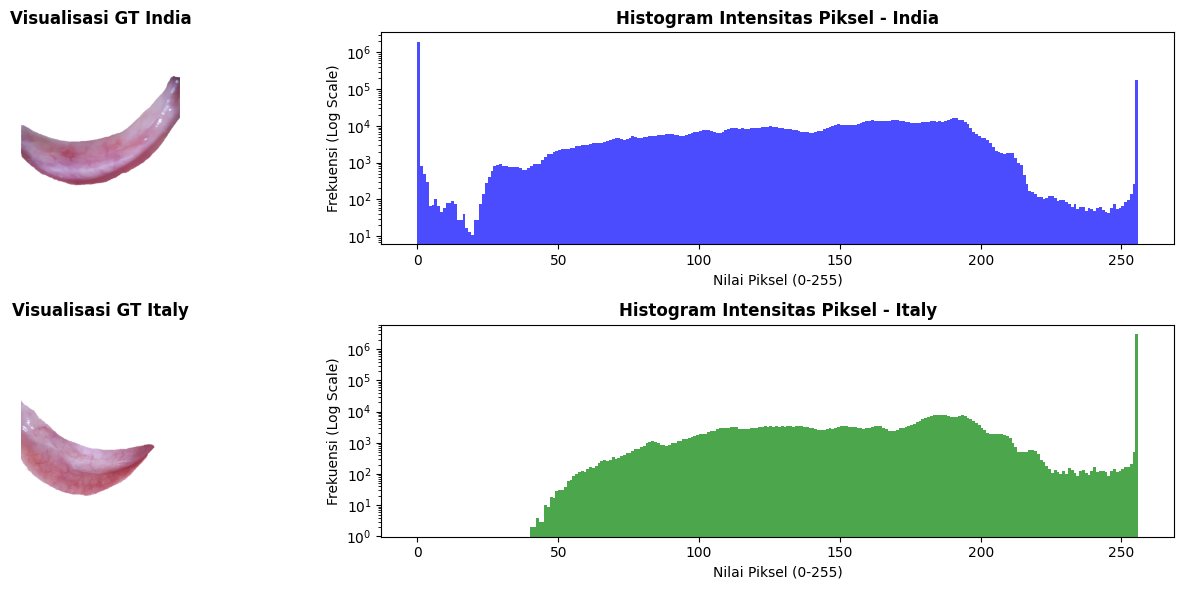

Menjalankan Skenario A


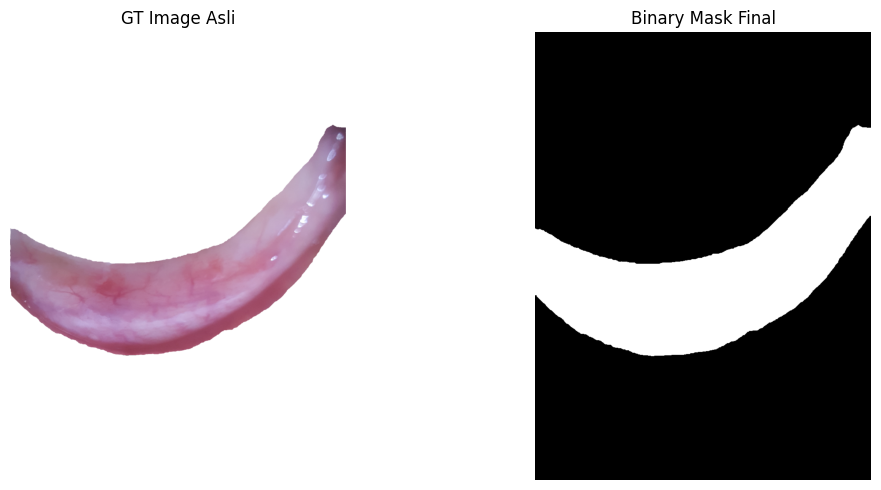

Menjalankan Skenario A


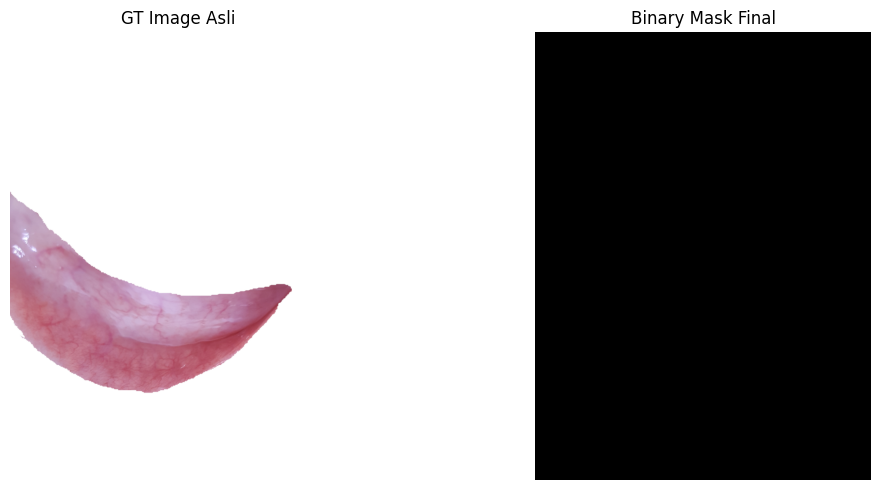

In [10]:
path_gt_india = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Dataset Eyedefy\India\12\20200203_103722_forniceal_palpebral.png'
path_gt_italy = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Dataset Eyedefy\Italy\6\006_forniceal_palpebral.png'

img_india = analyze_ground_truth("Dataset INDIA", path_gt_india)
img_italy = analyze_ground_truth("Dataset ITALY", path_gt_italy)

if img_india is not None and img_italy is not None:
    plot_comparative_histogram(img_india, img_italy)

'''_ = create_mask_hsv_method(path_gt_india)
_ = create_mask_hsv_method(path_gt_italy)
'''

_ = create_mask_method_v2(path_gt_india)
_ = create_mask_method_v2(path_gt_italy)